In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

from feature_extraction import extract_features
import joblib

In [3]:
dataset_path = "../dataset"

classes = ["normal", "cataract"]

X = []
y = []

for label in classes:

    folder = os.path.join(dataset_path, label)

    for file in os.listdir(folder):

        if not file.lower().endswith((".jpg",".jpeg",".png",".bmp")):
            continue

        path = os.path.join(folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        img = cv2.resize(img, (224,224))

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        features = extract_features(gray)

        X.append(features)

        if label == "cataract":
            y.append(1)
        else:
            y.append(0)

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))

libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


Total samples: 121


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
model = joblib.load("../models/cataract_detection.pkl")

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpick

In [8]:
y_prob = model.predict_proba(X_test)[:,1]

In [9]:
y_prob = model.predict_proba(X_test)[:,1]

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.1923076923076923


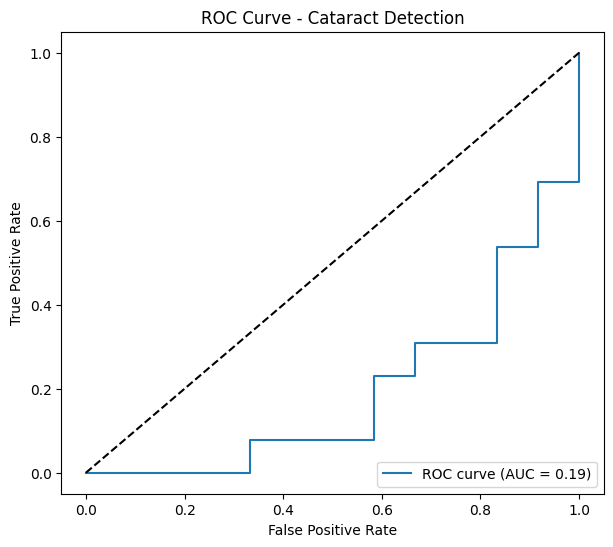

In [11]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="ROC curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Cataract Detection")

plt.legend(loc="lower right")

plt.show()